## **Imports**

In [2]:
import os
import glob
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, mean_absolute_error

## **Loading Model Fold Predictions**

In [9]:
# defining a function to load all fold predictions (10 CSV files) for each non-chemprop model
def load_fold_predictions(nam_conv):
    files = sorted(glob.glob(nam_conv))
    dfs = []
    for f in files:
        dfs.append(pd.read_csv(f))
    return dfs

### **Original Method**

In [32]:
# loading all 10 Random Forest model predictions
rf_folds = load_fold_predictions(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_RF/rf_outputs/rf_fold_preds/rf_fold*_predictions.csv')

In [94]:
# loading all 10 XGBoost model predictions
xgb_folds = load_fold_predictions(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_XGB/xgb_outputs/xgb_fold_preds/xgb_fold*_predictions.csv')

In [95]:
# loading all 10 LightGBM model predictions
lgbm_folds = load_fold_predictions(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_LGBM/lgbm_outputs/lgbm_fold_preds/lgbm_fold*_predictions.csv')

### **Improved Method**

In [96]:
# loading ensemble Random Forest model predictions
new_rf_preds = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_RF/new_outputs/rf_ensemble_preds.csv')

In [97]:
# loading ensemble XGBoost model predictions
new_lgbm_preds = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_LGBM/new_outputs/lgbm_ensemble_preds.csv')

In [98]:
# loading ensemble LightGBM model predictions
new_xgb_preds = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_XGB/new_outputs/xgb_ensemble_preds.csv')

### **Filtered Improved Method**

In [151]:
# loading ensemble Random Forest model predictions
filtered_rf_preds = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_RF/final_outputs/rf_ensemble_preds.csv')

In [136]:
# loading ensemble XGBoost model predictions
filtered_lgbm_preds = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_LGBM/final_outputs/lgbm_ensemble_preds.csv')

In [137]:
# loading ensemble LightGBM model predictions
filtered_xgb_preds = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_XGB/final_outputs/xgb_ensemble_preds.csv')

## **Random Forest Model**

### **Original Method**

### Obtaining Model Metrics from Output Summary File

In [45]:
# reading in the Random Forest model evaluation metric (mean and standard deviations) summary file produced during prediction
rf_summary = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_RF/rf_outputs/rf_metrics_summary.csv')
print(rf_summary)

                       Metric       Mean  Standard deviation
0    Absorption max (nm) RMSE  25.937705            1.586664
1  log(e/mol-1 dm3 cm-1) RMSE   0.250706            0.013977
2     Absorption max (nm) MAE  14.509682            0.457438
3   log(e/mol-1 dm3 cm-1) MAE   0.141942            0.004711


In [46]:
# extracting summary metrics obtained by the Random Forest model as a dictionary containing the target-specific evaluation metric, mean, and standard
# deviation values
rf_metrics = dict(zip(rf_summary['Metric'], zip(rf_summary['Mean'], rf_summary['Standard deviation'])))

# extracting each mean and standard deviation value for all unique target-specific error metrics
rf_mean_lambda_rmse, rf_lambda_rmse_sd = rf_metrics['Absorption max (nm) RMSE']
rf_mean_log_mec_rmse, rf_log_mec_rmse_sd = rf_metrics['log(e/mol-1 dm3 cm-1) RMSE']
rf_mean_lambda_mae, rf_lambda_mae_sd = rf_metrics['Absorption max (nm) MAE']
rf_mean_log_mec_mae, rf_log_mec_mae_sd = rf_metrics['log(e/mol-1 dm3 cm-1) MAE']

In [47]:
# printing extracted values to ensure they match the original Random Forest model metric summary file
print('RF Wavelength RMSE:', rf_mean_lambda_rmse, '+/-', rf_lambda_rmse_sd)
print('RF Wavelength MAE:', rf_mean_lambda_mae, '+/-', rf_lambda_mae_sd)
print('\nRF Log(molar extinction coefficient) RMSE:', rf_mean_log_mec_rmse, '+/-', rf_log_mec_rmse_sd)
print('RF Log(molar extinction coefficient) MAE:', rf_mean_log_mec_mae, '+/-', rf_log_mec_mae_sd)

Wavelength RMSE: 25.93770455 +/- 1.586664183
Wavelength MAE: 14.50968216 +/- 0.457438404

Log(molar extinction coefficient) RMSE: 0.250705675 +/- 0.013977466
Log(molar extinction coefficient) MAE: 0.141942166 +/- 0.004711013


### Creating Scatter Plots for Target Property Prediction Validation

In [57]:
# concatenating the length of all Random Forest fold predictions and viewing the length (same as full Deep4Chem dataset in this case due to model
# implementation)
rf_predictions = pd.concat(rf_folds, ignore_index=True)
len(rf_predictions)

7996

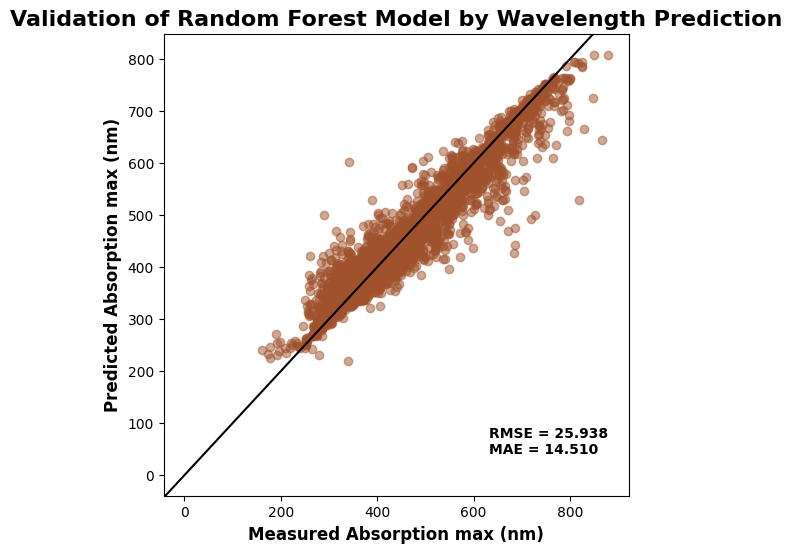

In [80]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(rf_predictions['True_wavelength'], rf_predictions['Pred_wavelength'], alpha=0.5, color='sienna')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Random Forest Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {rf_mean_lambda_rmse:.3f}\nMAE = {rf_mean_lambda_mae:.3f}', transform=plt.gca().transAxes, verticalalignment='top', 
         weight='bold')

plt.show()

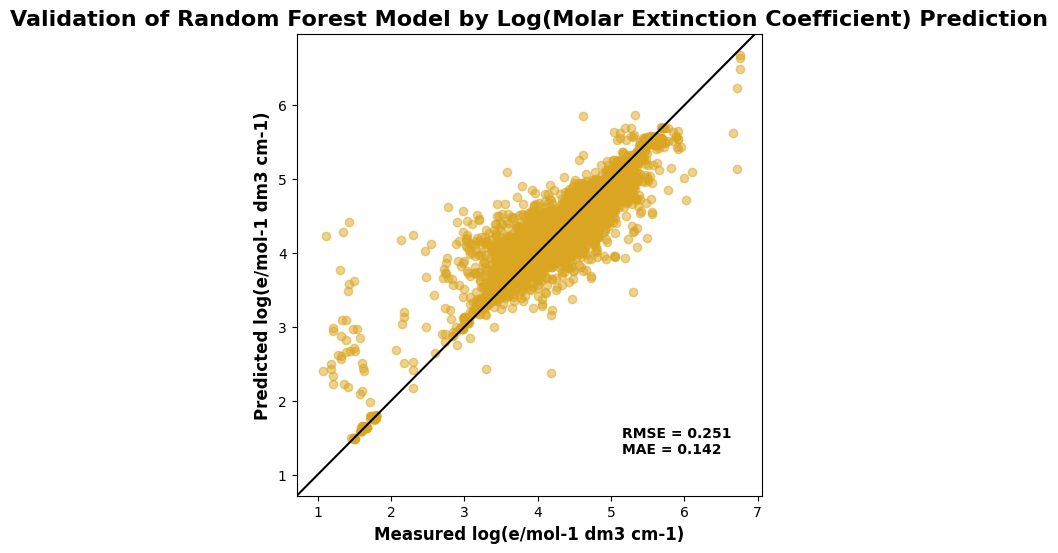

In [73]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(rf_predictions['True_log_mec'], rf_predictions['Pred_log_mec'], alpha=0.5, color='goldenrod')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Random Forest Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {rf_mean_log_mec_rmse:.3f}\nMAE = {rf_mean_log_mec_mae:.3f}', transform=plt.gca().transAxes, verticalalignment='top', 
         weight='bold')

plt.show()

### **Improved Method**

### Obtaining Model Metrics from Output Summary File

In [88]:
# reading in the Random Forest model evaluation metric (mean and standard deviations) summary file produced during prediction
new_rf_summary = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_RF/new_outputs/rf_metrics_summary.csv')
print(new_rf_summary)

                       Metric       Mean  Standard deviation
0    Absorption max (nm) RMSE  41.502328            0.167421
1  log(e/mol-1 dm3 cm-1) RMSE   0.358010            0.001680
2     Absorption max (nm) MAE  29.013945            0.089584
3   log(e/mol-1 dm3 cm-1) MAE   0.253141            0.000797


In [89]:
# extracting summary metrics obtained by the Random Forest model as a dictionary containing the target-specific evaluation metric, mean, and standard
# deviation values
new_rf_metrics = dict(zip(new_rf_summary['Metric'], zip(new_rf_summary['Mean'], new_rf_summary['Standard deviation'])))

# extracting each mean and standard deviation value for all unique target-specific error metrics
new_rf_mean_lambda_rmse, new_rf_lambda_rmse_sd = new_rf_metrics['Absorption max (nm) RMSE']
new_rf_mean_log_mec_rmse, new_rf_log_mec_rmse_sd = new_rf_metrics['log(e/mol-1 dm3 cm-1) RMSE']
new_rf_mean_lambda_mae, new_rf_lambda_mae_sd = new_rf_metrics['Absorption max (nm) MAE']
new_rf_mean_log_mec_mae, new_rf_log_mec_mae_sd = new_rf_metrics['log(e/mol-1 dm3 cm-1) MAE']

In [90]:
# printing extracted values to ensure they match the original Random Forest model metric summary file
print('RF Wavelength RMSE:', new_rf_mean_lambda_rmse, '+/-', new_rf_lambda_rmse_sd)
print('RF Wavelength MAE:', new_rf_mean_lambda_mae, '+/-', new_rf_lambda_mae_sd)
print('\nRF Log(molar extinction coefficient) RMSE:', new_rf_mean_log_mec_rmse, '+/-', new_rf_log_mec_rmse_sd)
print('RF Log(molar extinction coefficient) MAE:', new_rf_mean_log_mec_mae, '+/-', new_rf_log_mec_mae_sd)

RF Wavelength RMSE: 41.5023279463896 +/- 0.1674209669999623
RF Wavelength MAE: 29.013944744311328 +/- 0.0895842113418886

RF Log(molar extinction coefficient) RMSE: 0.3580104192724072 +/- 0.0016797178991043
RF Log(molar extinction coefficient) MAE: 0.2531410675080057 +/- 0.0007973933101145


### Creating Scatter Plots for Target Property Prediction Validation

In [91]:
# viewing the number of predictions obtained by the Random Forest model (same as the length of the Deep4Chem test subset due to model implementation)
len(new_rf_preds)

2059

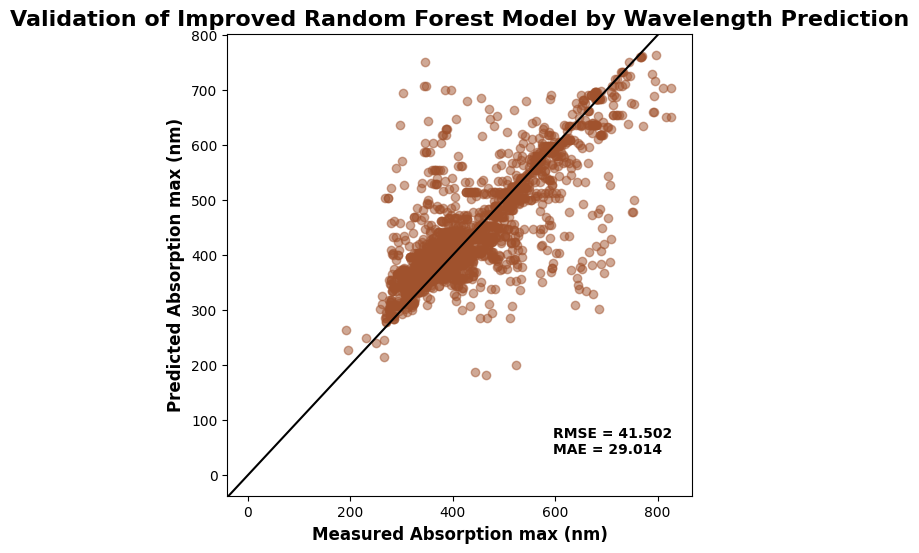

In [92]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(new_rf_preds['Absorption max (nm)'], new_rf_preds['Predicted Absorption max (nm)'], alpha=0.5, color='sienna')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Improved Random Forest Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {new_rf_mean_lambda_rmse:.3f}\nMAE = {new_rf_mean_lambda_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

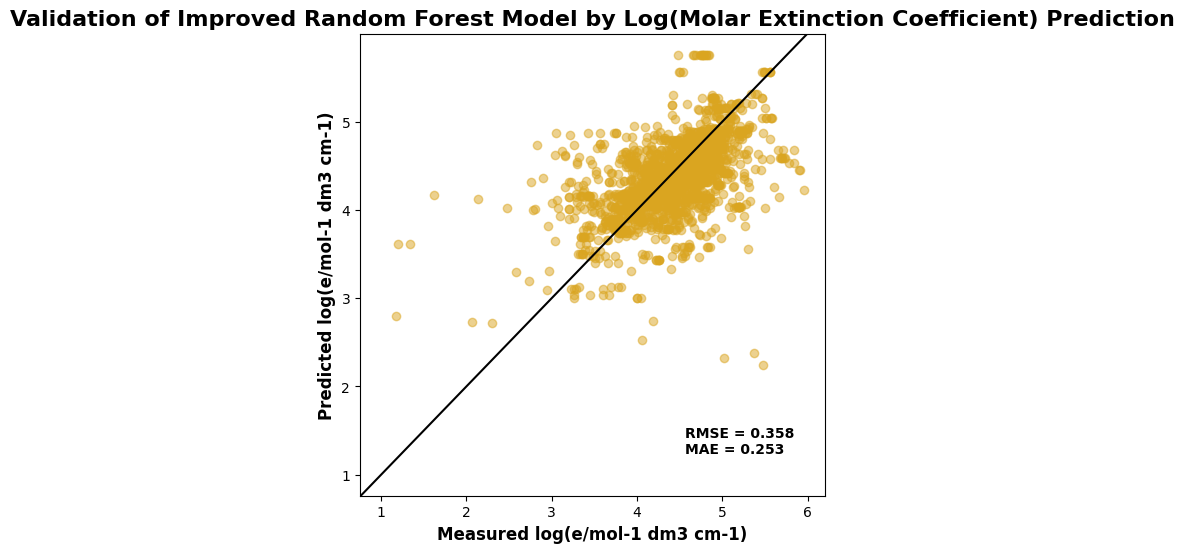

In [93]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(new_rf_preds['log(e/mol-1 dm3 cm-1)'], new_rf_preds['Predicted log(e/mol-1 dm3 cm-1)'], alpha=0.5, color='goldenrod')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Improved Random Forest Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {new_rf_mean_log_mec_rmse:.3f}\nMAE = {new_rf_mean_log_mec_mae:.3f}', transform=plt.gca().transAxes, verticalalignment='top', 
         weight='bold')

plt.show()

### **Filtered Improved Method**

### Obtaining Model Metrics from Output Summary File

In [118]:
# reading in the Random Forest model evaluation metric (mean and standard deviations) summary file produced during prediction
filtered_rf_summary = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_RF/opt_filtered_outputs/rf_metrics_summary.csv')
print(filtered_rf_summary)

                       Metric       Mean  Standard deviation
0    Absorption max (nm) RMSE  41.478674            0.277879
1  log(e/mol-1 dm3 cm-1) RMSE   0.350692            0.001721
2     Absorption max (nm) MAE  29.599651            0.169282
3   log(e/mol-1 dm3 cm-1) MAE   0.244665            0.001035


In [119]:
# extracting summary metrics obtained by the Random Forest model as a dictionary containing the target-specific evaluation metric, mean, and standard
# deviation values
filtered_rf_metrics = dict(zip(filtered_rf_summary['Metric'], zip(filtered_rf_summary['Mean'], filtered_rf_summary['Standard deviation'])))

# extracting each mean and standard deviation value for all unique target-specific error metrics
filtered_rf_mean_lambda_rmse, filtered_rf_lambda_rmse_sd = filtered_rf_metrics['Absorption max (nm) RMSE']
filtered_rf_mean_log_mec_rmse, filtered_rf_log_mec_rmse_sd = filtered_rf_metrics['log(e/mol-1 dm3 cm-1) RMSE']
filtered_rf_mean_lambda_mae, filtered_rf_lambda_mae_sd = filtered_rf_metrics['Absorption max (nm) MAE']
filtered_rf_mean_log_mec_mae, filtered_rf_log_mec_mae_sd = filtered_rf_metrics['log(e/mol-1 dm3 cm-1) MAE']

In [120]:
# printing extracted values to ensure they match the original Random Forest model metric summary file
print('Optimised RF Wavelength RMSE:', filtered_rf_mean_lambda_rmse, '+/-', filtered_rf_lambda_rmse_sd)
print('Optimised RF Wavelength MAE:', filtered_rf_mean_lambda_mae, '+/-', filtered_rf_lambda_mae_sd)
print('\nOptimised RF Log(molar extinction coefficient) RMSE:', filtered_rf_mean_log_mec_rmse, '+/-', filtered_rf_log_mec_rmse_sd)
print('Optimised RF Log(molar extinction coefficient) MAE:', filtered_rf_mean_log_mec_mae, '+/-', filtered_rf_log_mec_mae_sd)

Optimised RF Wavelength RMSE: 41.47867391410864 +/- 0.2778794904570916
Optimised RF Wavelength MAE: 29.59965141900826 +/- 0.1692824127334354

Optimised RF Log(molar extinction coefficient) RMSE: 0.3506922002178334 +/- 0.0017205042410378
Optimised RF Log(molar extinction coefficient) MAE: 0.2446650273822284 +/- 0.0010348987900214


### Creating Scatter Plots for Target Property Prediction Validation

In [152]:
# viewing the number of predictions obtained by the Random Forest model (same as the length of the Deep4Chem test subset due to model implementation)
len(filtered_rf_preds)

2056

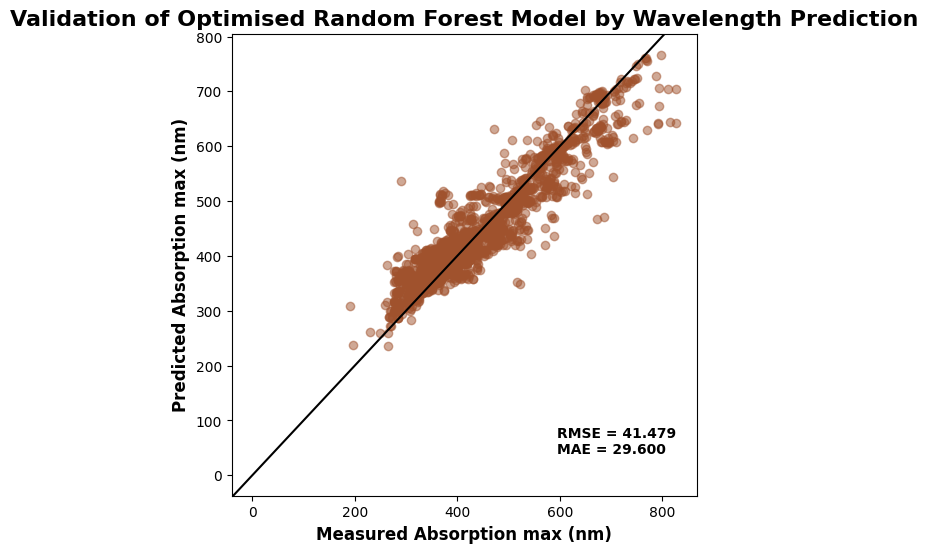

In [153]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(filtered_rf_preds['Absorption max (nm)'], filtered_rf_preds['Predicted Absorption max (nm)'], alpha=0.5, color='sienna')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Optimised Random Forest Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {filtered_rf_mean_lambda_rmse:.3f}\nMAE = {filtered_rf_mean_lambda_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

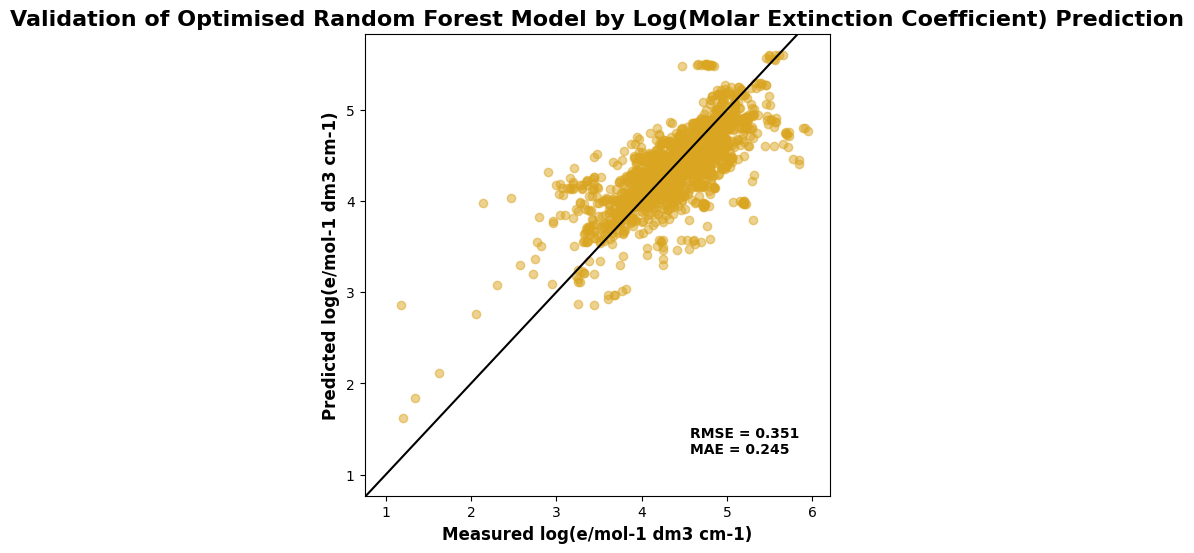

In [154]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(filtered_rf_preds['log(e/mol-1 dm3 cm-1)'], filtered_rf_preds['Predicted log(e/mol-1 dm3 cm-1)'], alpha=0.5, color='goldenrod')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Optimised Random Forest Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {filtered_rf_mean_log_mec_rmse:.3f}\nMAE = {filtered_rf_mean_log_mec_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

## **XGBoost Model**

### **Original Method**

### Obtaining Model Metrics from Output Summary File

In [58]:
# reading in the XGBoost model evaluation metric (mean and standard deviations) summary file produced during prediction
xgb_summary = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_XGB/xgb_outputs/xgb_metrics_summary.csv')
print(xgb_summary)

                       Metric       Mean  Standard deviation
0    Absorption max (nm) RMSE  22.688606            1.299071
1  log(e/mol-1 dm3 cm-1) RMSE   0.232584            0.013484
2     Absorption max (nm) MAE  13.052204            0.436400
3   log(e/mol-1 dm3 cm-1) MAE   0.137825            0.003198


In [59]:
# extracting summary metrics obtained by the XGBoost model as a dictionary containing the target-specific evaluation metric, mean, and standard
# deviation values
xgb_metrics = dict(zip(xgb_summary['Metric'], zip(xgb_summary['Mean'], xgb_summary['Standard deviation'])))

# extracting each mean and standard deviation value for all unique target-specific error metrics
xgb_mean_lambda_rmse, xgb_lambda_rmse_sd = xgb_metrics['Absorption max (nm) RMSE']
xgb_mean_log_mec_rmse, xgb_log_mec_rmse_sd = xgb_metrics['log(e/mol-1 dm3 cm-1) RMSE']
xgb_mean_lambda_mae, xgb_lambda_mae_sd = xgb_metrics['Absorption max (nm) MAE']
xgb_mean_log_mec_mae, xgb_log_mec_mae_sd = xgb_metrics['log(e/mol-1 dm3 cm-1) MAE']

In [60]:
# printing extracted values to ensure they match the original XGBoost model metric summary file
print('XGB Wavelength RMSE:', xgb_mean_lambda_rmse, '+/-', xgb_lambda_rmse_sd)
print('XGB Wavelength MAE:', xgb_mean_lambda_mae, '+/-', xgb_lambda_mae_sd)
print('\nXGB Log(molar extinction coefficient) RMSE:', xgb_mean_log_mec_rmse, '+/-', xgb_log_mec_rmse_sd)
print('XGB Log(molar extinction coefficient) MAE:', xgb_mean_log_mec_mae, '+/-', xgb_log_mec_mae_sd)

XGB Wavelength RMSE: 22.68860592 +/- 1.299071205
XGB Wavelength MAE: 13.05220442 +/- 0.436399847

XGB Log(molar extinction coefficient) RMSE: 0.232584221 +/- 0.013483943
XGB Log(molar extinction coefficient) MAE: 0.137825428 +/- 0.003198169


### Creating Scatter Plots for Target Property Prediction Validation

In [61]:
# concatenating the length of all XGBoost fold predictions and viewing the length (same as full Deep4Chem dataset in this case due to model
# implementation)
xgb_predictions = pd.concat(xgb_folds, ignore_index=True)
len(xgb_predictions)

7996

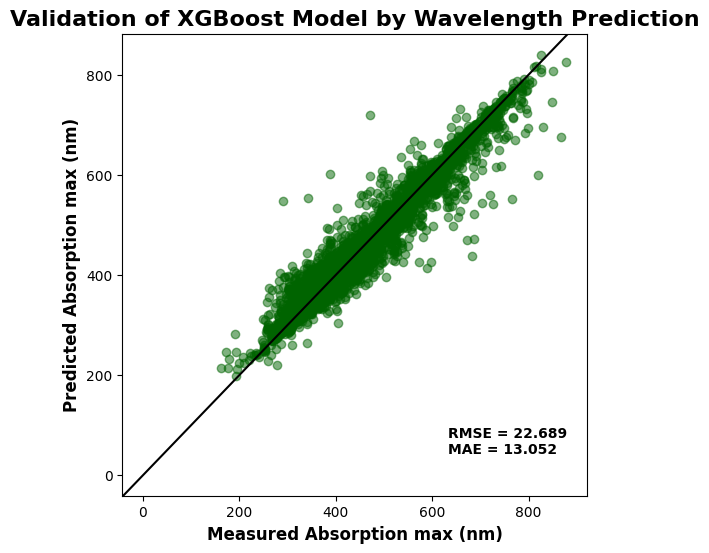

In [75]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(xgb_predictions['True_wavelength'], xgb_predictions['Pred_wavelength'], alpha=0.5, color='darkgreen')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of XGBoost Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {xgb_mean_lambda_rmse:.3f}\nMAE = {xgb_mean_lambda_mae:.3f}', transform=plt.gca().transAxes, verticalalignment='top', 
         weight='bold')

plt.show()

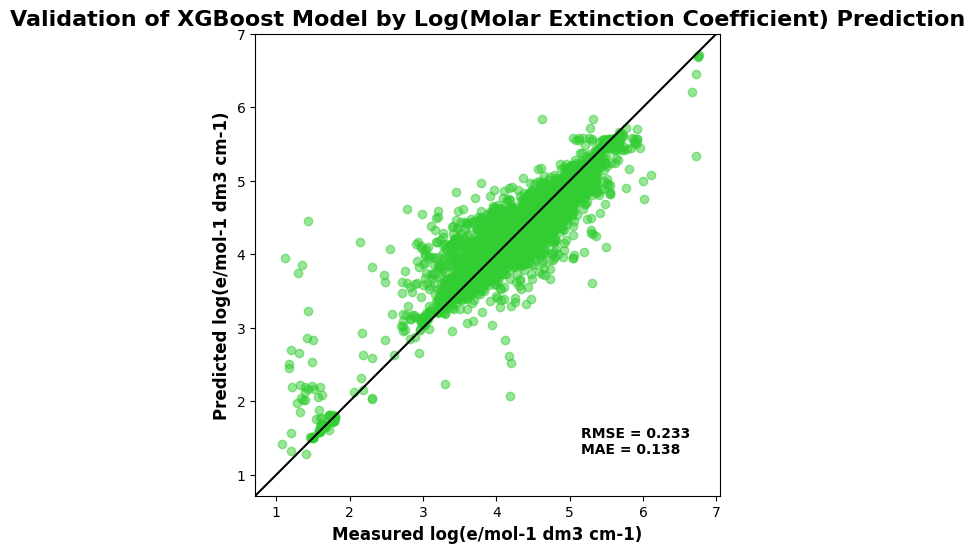

In [77]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(xgb_predictions['True_log_mec'], xgb_predictions['Pred_log_mec'], alpha=0.5, color='limegreen')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of XGBoost Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {xgb_mean_log_mec_rmse:.3f}\nMAE = {xgb_mean_log_mec_mae:.3f}', transform=plt.gca().transAxes, verticalalignment='top', 
         weight='bold')

plt.show()

### **Improved Method**

### Obtaining Model Metrics from Output Summary File

In [101]:
# reading in the XGBoost model evaluation metric (mean and standard deviations) summary file produced during prediction
new_xgb_summary = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_XGB/new_outputs/xgb_metrics_summary.csv')
print(new_xgb_summary)

                       Metric       Mean  Standard deviation
0    Absorption max (nm) RMSE  40.042559            0.430838
1  log(e/mol-1 dm3 cm-1) RMSE   0.355684            0.004197
2     Absorption max (nm) MAE  28.995531            0.368492
3   log(e/mol-1 dm3 cm-1) MAE   0.251034            0.002427


In [102]:
# extracting summary metrics obtained by the XGBoost model as a dictionary containing the target-specific evaluation metric, mean, and standard
# deviation values
new_xgb_metrics = dict(zip(new_xgb_summary['Metric'], zip(new_xgb_summary['Mean'], new_xgb_summary['Standard deviation'])))

# extracting each mean and standard deviation value for all unique target-specific error metrics
new_xgb_mean_lambda_rmse, new_xgb_lambda_rmse_sd = new_xgb_metrics['Absorption max (nm) RMSE']
new_xgb_mean_log_mec_rmse, new_xgb_log_mec_rmse_sd = new_xgb_metrics['log(e/mol-1 dm3 cm-1) RMSE']
new_xgb_mean_lambda_mae, new_xgb_lambda_mae_sd = new_xgb_metrics['Absorption max (nm) MAE']
new_xgb_mean_log_mec_mae, new_xgb_log_mec_mae_sd = new_xgb_metrics['log(e/mol-1 dm3 cm-1) MAE']

In [103]:
# printing extracted values to ensure they match the original XGBoost model metric summary file
print('XGB Wavelength RMSE:', new_xgb_mean_lambda_rmse, '+/-', new_xgb_lambda_rmse_sd)
print('XGB Wavelength MAE:', new_xgb_mean_lambda_mae, '+/-', new_xgb_lambda_mae_sd)
print('\nXGB Log(molar extinction coefficient) RMSE:', new_xgb_mean_log_mec_rmse, '+/-', new_xgb_log_mec_rmse_sd)
print('XGB Log(molar extinction coefficient) MAE:', new_xgb_mean_log_mec_mae, '+/-', new_xgb_log_mec_mae_sd)

XGB Wavelength RMSE: 40.04255920386549 +/- 0.4308379682786875
XGB Wavelength MAE: 28.99553130665249 +/- 0.368491765583798

XGB Log(molar extinction coefficient) RMSE: 0.3556836694116564 +/- 0.0041968337616064
XGB Log(molar extinction coefficient) MAE: 0.2510344518956189 +/- 0.0024267589503704


### Creating Scatter Plots for Target Property Prediction Validation

In [104]:
# viewing the number of predictions obtained by the XGBoost model (same as the length of the Deep4Chem test subset due to model implementation)
len(new_xgb_preds)

2059

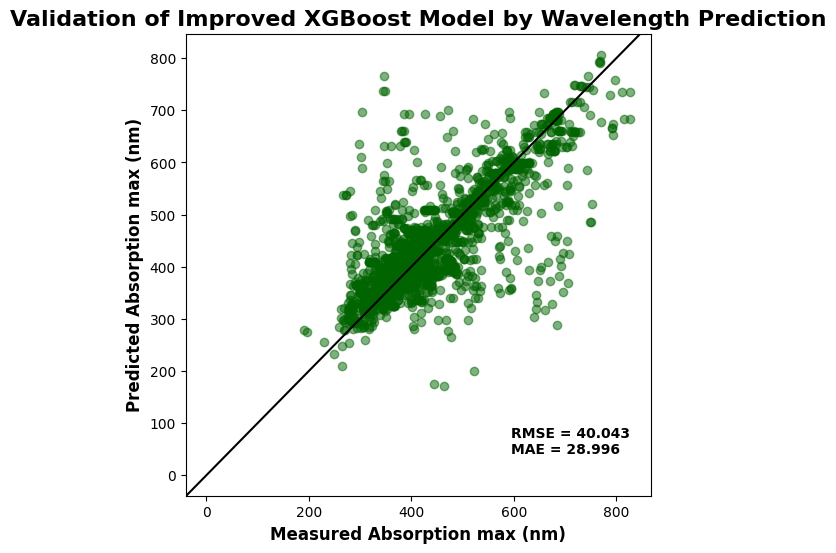

In [105]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(new_xgb_preds['Absorption max (nm)'], new_xgb_preds['Predicted Absorption max (nm)'], alpha=0.5, color='darkgreen')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Improved XGBoost Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {new_xgb_mean_lambda_rmse:.3f}\nMAE = {new_xgb_mean_lambda_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

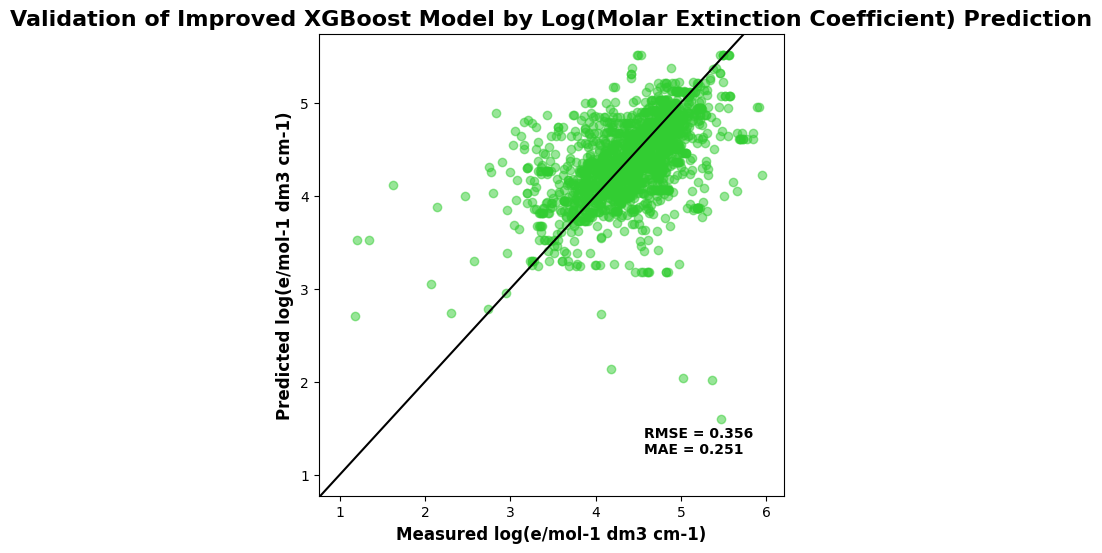

In [114]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(new_xgb_preds['log(e/mol-1 dm3 cm-1)'], new_xgb_preds['Predicted log(e/mol-1 dm3 cm-1)'], alpha=0.5, color='limegreen')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Improved XGBoost Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {new_xgb_mean_log_mec_rmse:.3f}\nMAE = {new_xgb_mean_log_mec_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

### **Filtered Improved Method**

### Obtaining Model Metrics from Output Summary File

In [139]:
# reading in the XGBoost model evaluation metric (mean and standard deviations) summary file produced during prediction
filtered_xgb_summary = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_XGB/final_outputs/xgb_metrics_summary.csv')
print(filtered_xgb_summary)

                       Metric       Mean  Standard deviation
0    Absorption max (nm) RMSE  41.902114            0.428868
1  log(e/mol-1 dm3 cm-1) RMSE   0.355880            0.006361
2     Absorption max (nm) MAE  29.992242            0.336797
3   log(e/mol-1 dm3 cm-1) MAE   0.250321            0.003694


In [140]:
# extracting summary metrics obtained by the XGBoost model as a dictionary containing the target-specific evaluation metric, mean, and standard
# deviation values
filtered_xgb_metrics = dict(zip(filtered_xgb_summary['Metric'], zip(filtered_xgb_summary['Mean'], filtered_xgb_summary['Standard deviation'])))

# extracting each mean and standard deviation value for all unique target-specific error metrics
filtered_xgb_mean_lambda_rmse, filtered_xgb_lambda_rmse_sd = filtered_xgb_metrics['Absorption max (nm) RMSE']
filtered_xgb_mean_log_mec_rmse, filtered_xgb_log_mec_rmse_sd = filtered_xgb_metrics['log(e/mol-1 dm3 cm-1) RMSE']
filtered_xgb_mean_lambda_mae, filtered_xgb_lambda_mae_sd = filtered_xgb_metrics['Absorption max (nm) MAE']
filtered_xgb_mean_log_mec_mae, filtered_xgb_log_mec_mae_sd = filtered_xgb_metrics['log(e/mol-1 dm3 cm-1) MAE']

In [141]:
# printing extracted values to ensure they match the original XGBoost model metric summary file
print('Optimised XGB Wavelength RMSE:', filtered_xgb_mean_lambda_rmse, '+/-', filtered_xgb_lambda_rmse_sd)
print('Optimised XGB Wavelength MAE:', filtered_xgb_mean_lambda_mae, '+/-', filtered_xgb_lambda_mae_sd)
print('\nOptimised XGB Log(molar extinction coefficient) RMSE:', filtered_xgb_mean_log_mec_rmse, '+/-', filtered_xgb_log_mec_rmse_sd)
print('Optimised XGB Log(molar extinction coefficient) MAE:', filtered_xgb_mean_log_mec_mae, '+/-', filtered_xgb_log_mec_mae_sd)

Optimised XGB Wavelength RMSE: 41.90211416096256 +/- 0.4288675695782349
Optimised XGB Wavelength MAE: 29.992242000512142 +/- 0.336797352443992

Optimised XGB Log(molar extinction coefficient) RMSE: 0.3558804500641697 +/- 0.0063613309403286
Optimised XGB Log(molar extinction coefficient) MAE: 0.2503214561534134 +/- 0.0036937419487651


### Creating Scatter Plots for Target Property Prediction Validation

In [142]:
# viewing the number of predictions obtained by the XGBoost model (same as the length of the Deep4Chem test subset due to model implementation)
len(filtered_xgb_preds)

2056

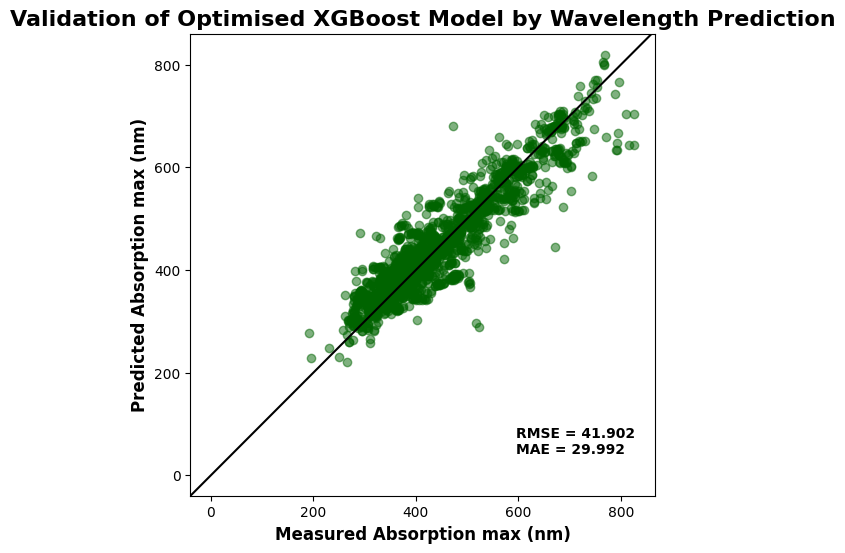

In [143]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(filtered_xgb_preds['Absorption max (nm)'], filtered_xgb_preds['Predicted Absorption max (nm)'], alpha=0.5, color='darkgreen')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Optimised XGBoost Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {filtered_xgb_mean_lambda_rmse:.3f}\nMAE = {filtered_xgb_mean_lambda_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

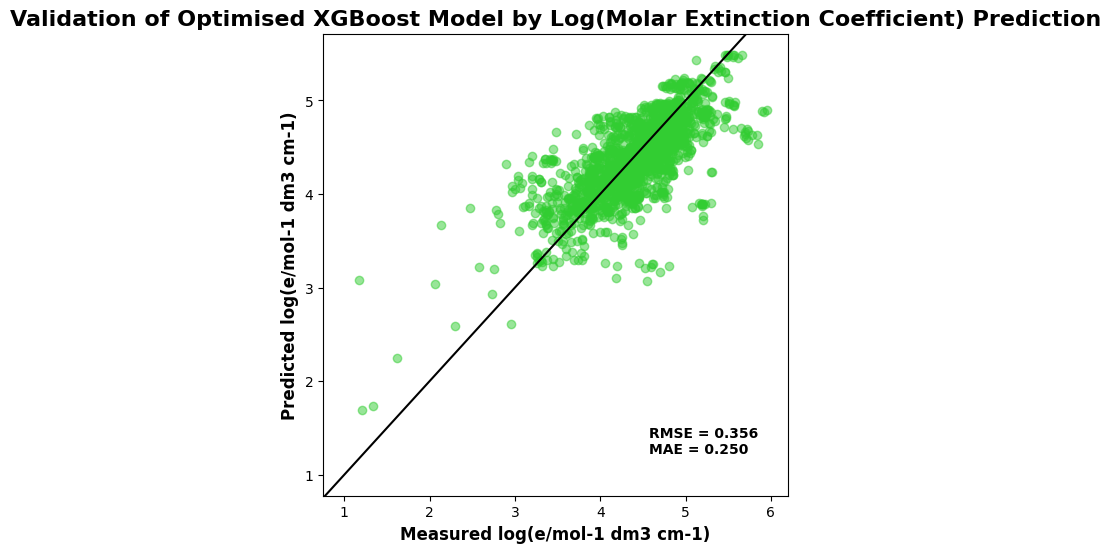

In [144]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(filtered_xgb_preds['log(e/mol-1 dm3 cm-1)'], filtered_xgb_preds['Predicted log(e/mol-1 dm3 cm-1)'], alpha=0.5, color='limegreen')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Optimised XGBoost Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {filtered_xgb_mean_log_mec_rmse:.3f}\nMAE = {filtered_xgb_mean_log_mec_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

## **LightGBM Model**

### **Original Method**

### Obtaining Model Metrics from Output Summary File

In [64]:
# reading in the LightGBM model evaluation metric (mean and standard deviations) summary file produced during prediction
lgbm_summary = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_LGBM/lgbm_outputs/lgbm_metrics_summary.csv')
print(lgbm_summary)

                       Metric       Mean  Standard deviation
0    Absorption max (nm) RMSE  22.916782            1.401138
1  log(e/mol-1 dm3 cm-1) RMSE   0.229672            0.014808
2     Absorption max (nm) MAE  13.042048            0.542521
3   log(e/mol-1 dm3 cm-1) MAE   0.134701            0.003816


In [65]:
# extracting summary metrics obtained by the LightGBM model as a dictionary containing the target-specific evaluation metric, mean, and standard
# deviation values
lgbm_metrics = dict(zip(lgbm_summary['Metric'], zip(lgbm_summary['Mean'], lgbm_summary['Standard deviation'])))

# extracting each mean and standard deviation value for all unique target-specific error metrics
lgbm_mean_lambda_rmse, lgbm_lambda_rmse_sd = lgbm_metrics['Absorption max (nm) RMSE']
lgbm_mean_log_mec_rmse, lgbm_log_mec_rmse_sd = lgbm_metrics['log(e/mol-1 dm3 cm-1) RMSE']
lgbm_mean_lambda_mae, lgbm_lambda_mae_sd = lgbm_metrics['Absorption max (nm) MAE']
lgbm_mean_log_mec_mae, lgbm_log_mec_mae_sd = lgbm_metrics['log(e/mol-1 dm3 cm-1) MAE']

In [66]:
# printing extracted values to ensure they match the original LightGBM model metric summary file
print('LGBM Wavelength RMSE:', lgbm_mean_lambda_rmse, '+/-', lgbm_lambda_rmse_sd)
print('LGBM Wavelength MAE:', lgbm_mean_lambda_mae, '+/-', lgbm_lambda_mae_sd)
print('\nLGBM Log(molar extinction coefficient) RMSE:', lgbm_mean_log_mec_rmse, '+/-', lgbm_log_mec_rmse_sd)
print('LGBM Log(molar extinction coefficient) MAE:', lgbm_mean_log_mec_mae, '+/-', lgbm_log_mec_mae_sd)

LGBM Wavelength RMSE: 22.91678187 +/- 1.40113837
LGBM Wavelength MAE: 13.04204754 +/- 0.542520824

LGBM Log(molar extinction coefficient) RMSE: 0.22967204 +/- 0.014808461
LGBM Log(molar extinction coefficient) MAE: 0.134701459 +/- 0.003816195


### Creating Scatter Plots for Target Property Prediction Validation

In [67]:
# concatenating the length of all LightGBM fold predictions and viewing the length (same as full Deep4Chem dataset in this case due to model
# implementation)
lgbm_predictions = pd.concat(lgbm_folds, ignore_index=True)
len(lgbm_predictions)

7996

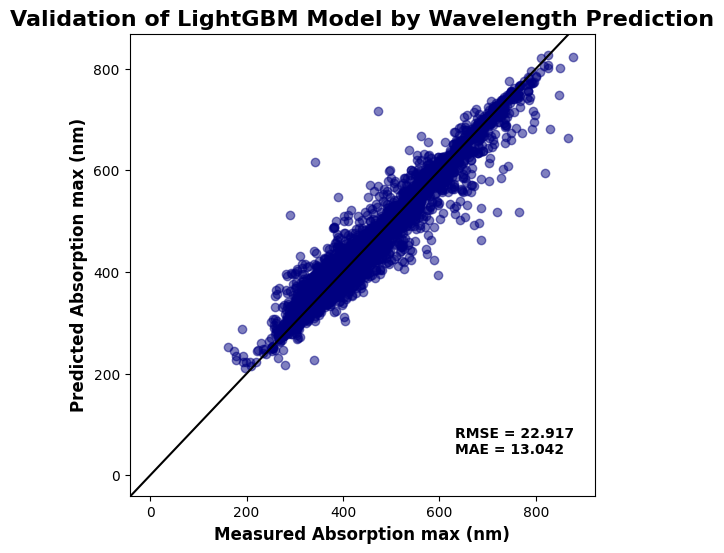

In [78]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(lgbm_predictions['True_wavelength'], lgbm_predictions['Pred_wavelength'], alpha=0.5, color='navy')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of LightGBM Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {lgbm_mean_lambda_rmse:.3f}\nMAE = {lgbm_mean_lambda_mae:.3f}', transform=plt.gca().transAxes, verticalalignment='top', 
         weight='bold')

plt.show()

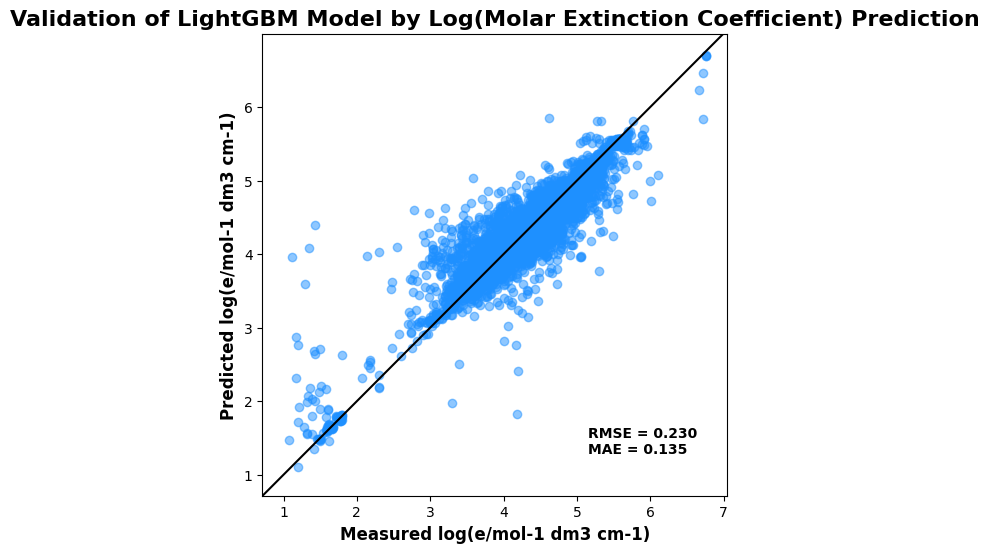

In [79]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(lgbm_predictions['True_log_mec'], lgbm_predictions['Pred_log_mec'], alpha=0.5, color='dodgerblue')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of LightGBM Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {lgbm_mean_log_mec_rmse:.3f}\nMAE = {lgbm_mean_log_mec_mae:.3f}', transform=plt.gca().transAxes, verticalalignment='top', 
         weight='bold')

plt.show()

### **Improved Method**

### Obtaining Model Metrics from Output Summary File

In [107]:
# reading in the LightGBM model evaluation metric (mean and standard deviations) summary file produced during prediction
new_lgbm_summary = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_LGBM/new_outputs/lgbm_metrics_summary.csv')
print(new_lgbm_summary)

                       Metric       Mean  Standard deviation
0    Absorption max (nm) RMSE  42.219865            0.793250
1  log(e/mol-1 dm3 cm-1) RMSE   0.367488            0.004339
2     Absorption max (nm) MAE  29.663639            0.674302
3   log(e/mol-1 dm3 cm-1) MAE   0.256145            0.003776


In [108]:
# extracting summary metrics obtained by the LightGBM model as a dictionary containing the target-specific evaluation metric, mean, and standard
# deviation values
new_lgbm_metrics = dict(zip(new_lgbm_summary['Metric'], zip(new_lgbm_summary['Mean'], new_lgbm_summary['Standard deviation'])))

# extracting each mean and standard deviation value for all unique target-specific error metrics
new_lgbm_mean_lambda_rmse, new_lgbm_lambda_rmse_sd = new_lgbm_metrics['Absorption max (nm) RMSE']
new_lgbm_mean_log_mec_rmse, new_lgbm_log_mec_rmse_sd = new_lgbm_metrics['log(e/mol-1 dm3 cm-1) RMSE']
new_lgbm_mean_lambda_mae, new_lgbm_lambda_mae_sd = new_lgbm_metrics['Absorption max (nm) MAE']
new_lgbm_mean_log_mec_mae, new_lgbm_log_mec_mae_sd = new_lgbm_metrics['log(e/mol-1 dm3 cm-1) MAE']

In [109]:
# printing extracted values to ensure they match the original LightGBM model metric summary file
print('LGBM Wavelength RMSE:', new_lgbm_mean_lambda_rmse, '+/-', new_lgbm_lambda_rmse_sd)
print('LGBM Wavelength MAE:', new_lgbm_mean_lambda_mae, '+/-', new_lgbm_lambda_mae_sd)
print('\nLGBM Log(molar extinction coefficient) RMSE:', new_lgbm_mean_log_mec_rmse, '+/-', new_lgbm_log_mec_rmse_sd)
print('LGBM Log(molar extinction coefficient) MAE:', new_lgbm_mean_log_mec_mae, '+/-', new_lgbm_log_mec_mae_sd)

LGBM Wavelength RMSE: 42.21986525658505 +/- 0.7932497544614279
LGBM Wavelength MAE: 29.6636387367084 +/- 0.6743016573635248

LGBM Log(molar extinction coefficient) RMSE: 0.3674878925466792 +/- 0.0043389859255967
LGBM Log(molar extinction coefficient) MAE: 0.2561452084073593 +/- 0.0037755750595579


### Creating Scatter Plots for Target Property Prediction Validation

In [110]:
# viewing the number of predictions obtained by the LightGBM model (same as the length of the Deep4Chem test subset due to model implementation)
len(new_lgbm_preds)

2059

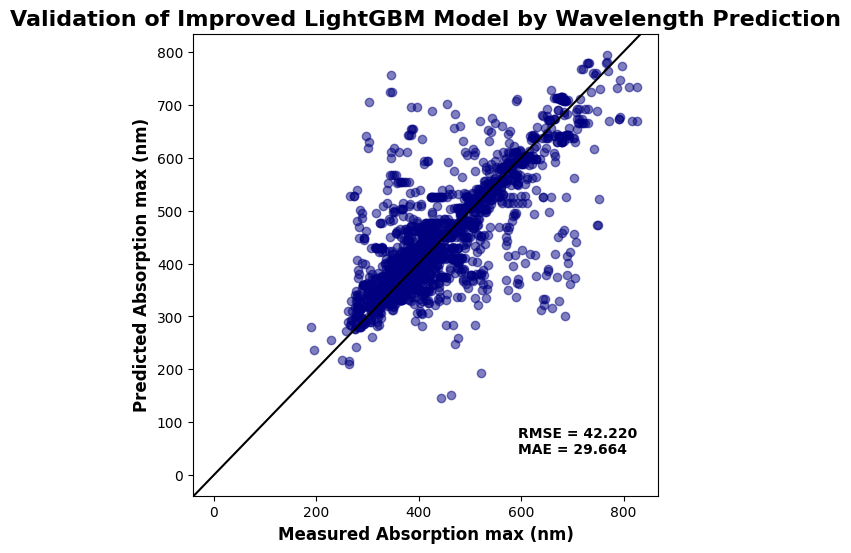

In [111]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(new_lgbm_preds['Absorption max (nm)'], new_lgbm_preds['Predicted Absorption max (nm)'], alpha=0.5, color='navy')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Improved LightGBM Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {new_lgbm_mean_lambda_rmse:.3f}\nMAE = {new_lgbm_mean_lambda_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

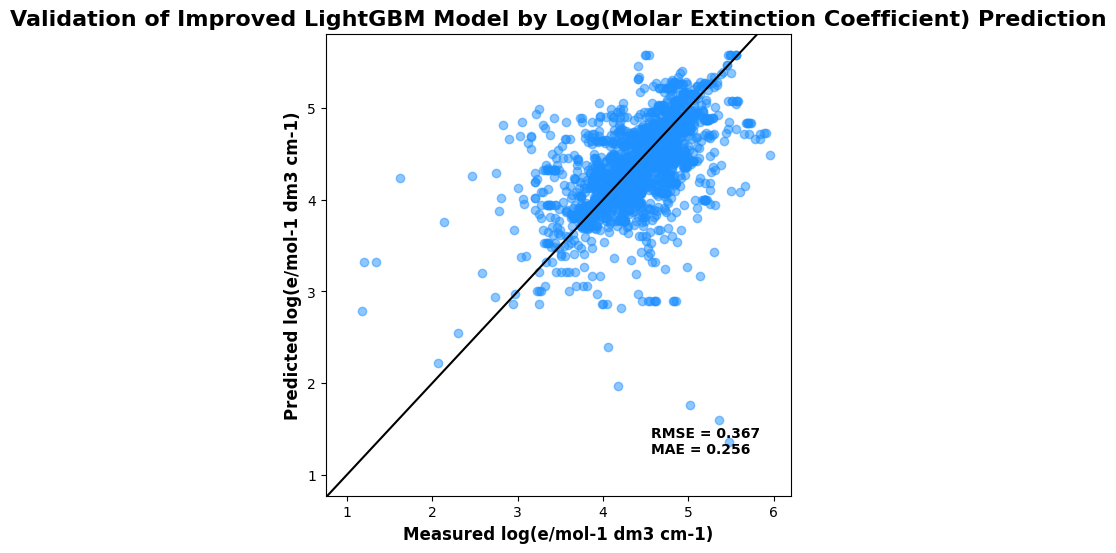

In [112]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(new_lgbm_preds['log(e/mol-1 dm3 cm-1)'], new_lgbm_preds['Predicted log(e/mol-1 dm3 cm-1)'], alpha=0.5, color='dodgerblue')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Improved LightGBM Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {new_lgbm_mean_log_mec_rmse:.3f}\nMAE = {new_lgbm_mean_log_mec_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

### **Filtered Improved Method**

### Obtaining Model Metrics from Output Summary File

In [145]:
# reading in the LightGBM model evaluation metric (mean and standard deviations) summary file produced during prediction
filtered_lgbm_summary = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_LGBM/final_outputs/lgbm_metrics_summary.csv')
print(filtered_lgbm_summary)

                       Metric       Mean  Standard deviation
0    Absorption max (nm) RMSE  42.606060            1.016046
1  log(e/mol-1 dm3 cm-1) RMSE   0.370673            0.008148
2     Absorption max (nm) MAE  29.931630            0.508408
3   log(e/mol-1 dm3 cm-1) MAE   0.252830            0.004921


In [146]:
# extracting summary metrics obtained by the LightGBM model as a dictionary containing the target-specific evaluation metric, mean, and standard
# deviation values
filtered_lgbm_metrics = dict(zip(filtered_lgbm_summary['Metric'], zip(filtered_lgbm_summary['Mean'], filtered_lgbm_summary['Standard deviation'])))

# extracting each mean and standard deviation value for all unique target-specific error metrics
filtered_lgbm_mean_lambda_rmse, filtered_lgbm_lambda_rmse_sd = filtered_lgbm_metrics['Absorption max (nm) RMSE']
filtered_lgbm_mean_log_mec_rmse, filtered_lgbm_log_mec_rmse_sd = filtered_lgbm_metrics['log(e/mol-1 dm3 cm-1) RMSE']
filtered_lgbm_mean_lambda_mae, filtered_lgbm_lambda_mae_sd = filtered_lgbm_metrics['Absorption max (nm) MAE']
filtered_lgbm_mean_log_mec_mae, filtered_lgbm_log_mec_mae_sd = filtered_lgbm_metrics['log(e/mol-1 dm3 cm-1) MAE']

In [147]:
# printing extracted values to ensure they match the original LightGBM model metric summary file
print('Optimised LGBM Wavelength RMSE:', filtered_lgbm_mean_lambda_rmse, '+/-', filtered_lgbm_lambda_rmse_sd)
print('Optimised LGBM Wavelength MAE:', filtered_lgbm_mean_lambda_mae, '+/-', filtered_lgbm_lambda_mae_sd)
print('\nOptimised LGBM Log(molar extinction coefficient) RMSE:', filtered_lgbm_mean_log_mec_rmse, '+/-', filtered_lgbm_log_mec_rmse_sd)
print('Optimised LGBM Log(molar extinction coefficient) MAE:', filtered_lgbm_mean_log_mec_mae, '+/-', filtered_lgbm_log_mec_mae_sd)

Optimised LGBM Wavelength RMSE: 42.60605968114 +/- 1.0160459296686384
Optimised LGBM Wavelength MAE: 29.931629913620167 +/- 0.5084078352477496

Optimised LGBM Log(molar extinction coefficient) RMSE: 0.3706726736157474 +/- 0.0081479321442222
Optimised LGBM Log(molar extinction coefficient) MAE: 0.2528298436221095 +/- 0.0049214397871698


### Creating Scatter Plots for Target Property Prediction Validation

In [148]:
# viewing the number of predictions obtained by the LightGBM model (same as the length of the Deep4Chem test subset due to model implementation)
len(filtered_lgbm_preds)

2056

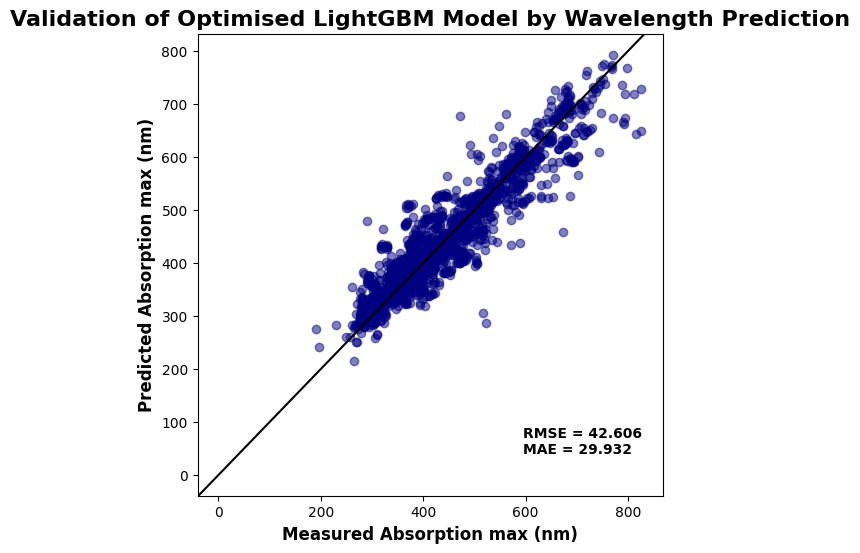

In [149]:
# creating scatter plot to visualise evaluation metrics for wavelength
plt.figure(figsize=(6,6))
plt.scatter(filtered_lgbm_preds['Absorption max (nm)'], filtered_lgbm_preds['Predicted Absorption max (nm)'], alpha=0.5, color='navy')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured Absorption max (nm)', fontsize=12, weight='bold')
plt.ylabel('Predicted Absorption max (nm)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Optimised LightGBM Model by Wavelength Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {filtered_lgbm_mean_lambda_rmse:.3f}\nMAE = {filtered_lgbm_mean_lambda_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

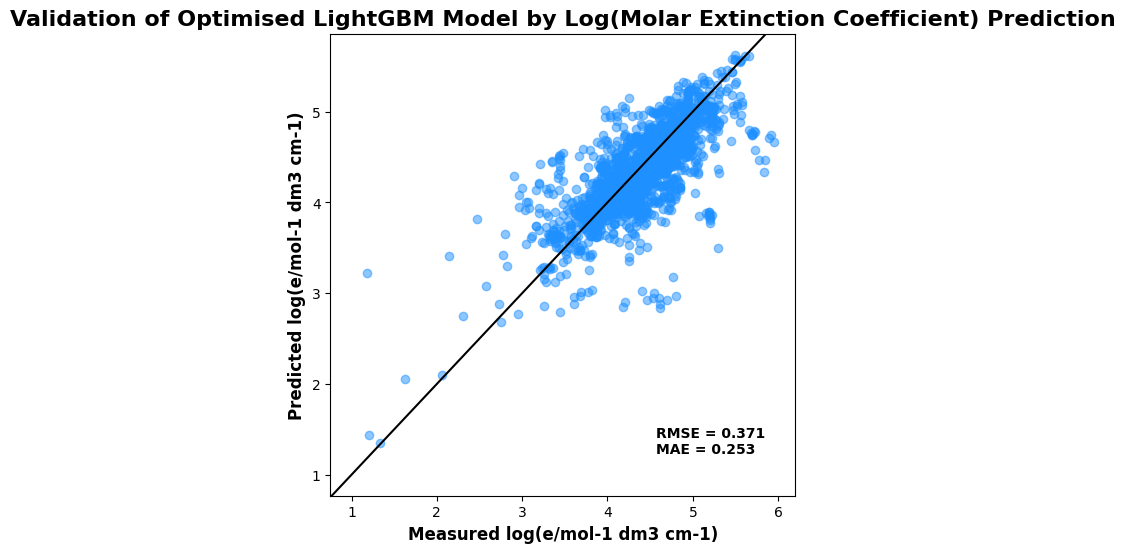

In [150]:
# creating scatter plot to visualise evaluation metrics for molar extinction coefficient
plt.figure(figsize=(6,6))
plt.scatter(filtered_lgbm_preds['log(e/mol-1 dm3 cm-1)'], filtered_lgbm_preds['Predicted log(e/mol-1 dm3 cm-1)'], alpha=0.5, color='dodgerblue')

# adding ideal prediction line (R^2 = 1)
plt.axline((1,1), slope=1, color='black')

# labelling axes
plt.xlabel('Measured log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.ylabel('Predicted log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')

# titling plot
plt.title('Validation of Optimised LightGBM Model by Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')

# adding text to display obtained mean evaluation metric values
plt.text(0.70, 0.15, f'RMSE = {filtered_lgbm_mean_log_mec_rmse:.3f}\nMAE = {filtered_lgbm_mean_log_mec_mae:.3f}', transform=plt.gca().transAxes, 
         verticalalignment='top', weight='bold')

plt.show()

## **Producing Combined Prediction Metrics Plots for Reporting**

In [171]:
# creating a list variable to store each tree-based model, and tranforming that into x-axes for the following plots
models = ['Random Forest', 'XGBoost', 'LightGBM']
x = np.arange(len(models))

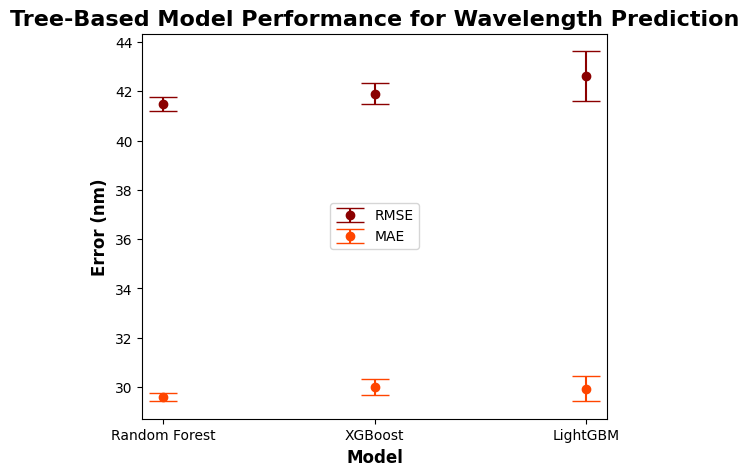

In [183]:
# creating lists containing every model's mean and standard deviation value for each wavelength-specific error metric
lambda_rmse_mean = [filtered_rf_mean_lambda_rmse, filtered_xgb_mean_lambda_rmse, filtered_lgbm_mean_lambda_rmse]
lambda_rmse_sd = [filtered_rf_lambda_rmse_sd, filtered_xgb_lambda_rmse_sd, filtered_lgbm_lambda_rmse_sd]
lambda_mae_mean = [filtered_rf_mean_lambda_mae, filtered_xgb_mean_lambda_mae, filtered_lgbm_mean_lambda_mae]
lambda_mae_sd = [filtered_rf_lambda_mae_sd, filtered_xgb_lambda_mae_sd, filtered_lgbm_lambda_mae_sd]

# creating a plot to combine wavelength prediction metrics for all three models
plt.figure(figsize=(6, 5))
# creating points for the plot representing the ensemble wavelength metric values, with standard deviations being represented by the error bars
plt.errorbar(x, lambda_rmse_mean, yerr=lambda_rmse_sd, fmt='o', capsize=10, label='RMSE', color='darkred')
plt.errorbar(x, lambda_mae_mean, yerr=lambda_mae_sd, fmt='o', capsize=10, label='MAE', color='orangered')
# labelling axes and titling plot
plt.xlabel('Model', fontsize=12, weight='bold')
plt.xticks(x, models)
plt.ylabel('Error (nm)', fontsize=12, weight='bold')
plt.title('Tree-Based Model Performance for Wavelength Prediction', fontsize=16, weight='bold')
# placing legend in the middle of the plot
plt.legend(loc=10)
plt.show()

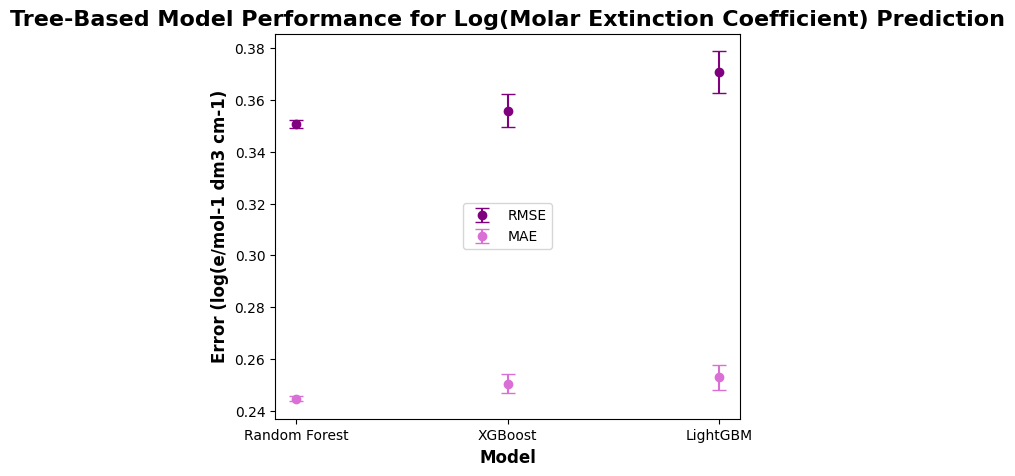

In [182]:
# creating lists containing every model's mean and standard deviation value for each log(molar extinction coefficient)-specific error metric
loge_rmse_mean = [filtered_rf_mean_log_mec_rmse, filtered_xgb_mean_log_mec_rmse, filtered_lgbm_mean_log_mec_rmse]
loge_rmse_sd = [filtered_rf_log_mec_rmse_sd, filtered_xgb_log_mec_rmse_sd, filtered_lgbm_log_mec_rmse_sd]
loge_mae_mean = [filtered_rf_mean_log_mec_mae, filtered_xgb_mean_log_mec_mae, filtered_lgbm_mean_log_mec_mae]
loge_mae_sd = [filtered_rf_log_mec_mae_sd, filtered_xgb_log_mec_mae_sd,filtered_lgbm_log_mec_mae_sd]

# creating a plot to combine log(molar extinction coefficient) prediction metrics for all three models
plt.figure(figsize=(6, 5))
# creating points for the plot representing the ensemble log(molar extinction coefficient) metric values, with standard deviations being represented by
# the error bars
plt.errorbar(x, loge_rmse_mean, yerr=loge_rmse_sd, fmt='o', capsize=5, label='RMSE', color='purple')
plt.errorbar(x, loge_mae_mean, yerr=loge_mae_sd, fmt='o', capsize=5, label='MAE', color='orchid')
# labelling axes and titling plot
plt.xlabel('Model', fontsize=12, weight='bold')
plt.xticks(x, models)
plt.ylabel('Error (log(e/mol-1 dm3 cm-1)', fontsize=12, weight='bold')
plt.title('Tree-Based Model Performance for Log(Molar Extinction Coefficient) Prediction', fontsize=16, weight='bold')
# placing legend in the middle of the plot
plt.legend(loc=10)
plt.show()

## **Producing SHAP Analysis Result Plots for Reporting**

In [186]:
# loading all feature summary files obtained for each of the three tree-based models
rf_wavelength = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_RF/final_outputs/rf_wavelength_feature_summary.csv')
xgb_wavelength = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_XGB/final_outputs/xgb_wavelength_feature_summary.csv')
lgbm_wavelength = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_LGBM/final_outputs/lgbm_wavelength_feature_summary.csv')

rf_loge = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_RF/final_outputs/rf_log_mec_feature_summary.csv')
xgb_loge = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_XGB/final_outputs/xgb_log_mec_feature_summary.csv')
lgbm_loge = pd.read_csv(r'C:/Users/Amy/Desktop/Masters_Project/paper_methods/Deep4Chem_LGBM/final_outputs/lgbm_log_mec_feature_summary.csv')

In [221]:
# defining a function to create comparison plots
def plot_mean_shap(rf, xgb, lgbm, title, top_n=5):
    # selecting the top N descriptors for each model
    rf_top = rf.nlargest(top_n, 'Mean_SHAP')
    xgb_top = xgb.nlargest(top_n, 'Mean_SHAP')
    lgbm_top = lgbm.nlargest(top_n, 'Mean_SHAP')

    # merging descriptors occurring in any top-N list
    features = list(dict.fromkeys(list(rf_top['Feature']) + list(xgb_top['Feature']) + list(lgbm_top['Feature'])))

    # creating lookup dictionaries for mean and standard deviations for all models' SHAP values
    rf_mean = dict(zip(rf['Feature'], rf['Mean_SHAP']))
    xgb_mean = dict(zip(xgb['Feature'], xgb['Mean_SHAP']))
    lgbm_mean = dict(zip(lgbm['Feature'], lgbm['Mean_SHAP']))

    rf_sd = dict(zip(rf['Feature'], rf['SD_SHAP']))
    xgb_sd = dict(zip(xgb['Feature'], xgb['SD_SHAP']))
    lgbm_sd = dict(zip(lgbm['Feature'], lgbm['SD_SHAP']))

    # extracting mean and standard deviation feature values for each model - 0 if feature is absent
    rf_values = [rf_mean.get(f, 0) for f in features]
    xgb_values = [xgb_mean.get(f, 0) for f in features]
    lgbm_values = [lgbm_mean.get(f, 0) for f in features]

    rf_errors = [rf_sd.get(f, 0) for f in features]
    xgb_errors = [xgb_sd.get(f, 0) for f in features]
    lgbm_errors = [lgbm_sd.get(f, 0) for f in features]

    # sorting descriptors by descending average SHAP values across models
    overall_mean = np.mean([rf_values, xgb_values, lgbm_values], axis=0)

    order = np.argsort(overall_mean)[::-1]

    features = [features[i] for i in order]
    rf_values = np.array(rf_values)[order]
    xgb_values = np.array(xgb_values)[order]
    lgbm_values = np.array(lgbm_values)[order]

    rf_errors = np.array(rf_errors)[order]
    xgb_errors = np.array(xgb_errors)[order]
    lgbm_errors = np.array(lgbm_errors)[order]

    # plotting results obtained for each model
    x = np.arange(len(features))
    width = 0.25

    plt.figure(figsize=(14, 7))
    # creating points for the plot representing the ensemble log(molar extinction coefficient) metric values, with standard deviations being 
    # represented by the error bars
    plt.bar(x - width, rf_values, width, yerr=rf_errors, capsize=10, label='Random Forest', color='indigo')
    plt.bar(x, xgb_values, width, yerr=xgb_errors, capsize=10, label='XGBoost', color='plum')
    plt.bar(x + width, lgbm_values, width, yerr=lgbm_errors, capsize=10, label='LightGBM', color='mediumorchid')

    # labelling axes and titling plot
    plt.xlabel('RDKit Molecular Descriptor', fontsize=12, weight='bold')
    plt.xticks(x, features,rotation=45, ha='right')
    plt.ylabel('Mean absolute SHAP value', fontsize=12, weight='bold')
    plt.title(title, fontsize=16, weight='bold')
    
    plt.legend()
    plt.tight_layout()
    plt.show()

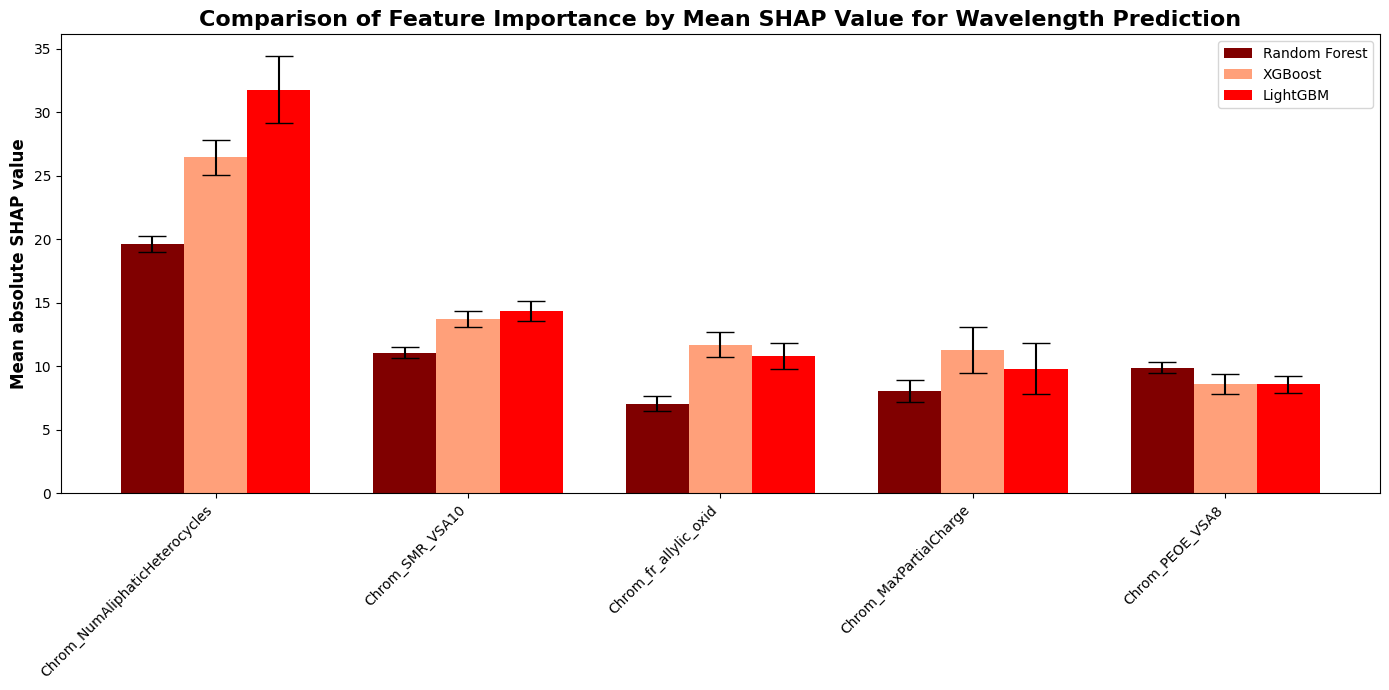

In [216]:
# generating the wavelength SHAP feature figure
plot_mean_shap(rf_wavelength, xgb_wavelength, lgbm_wavelength, title='Comparison of Feature Importance by Mean SHAP Value for Wavelength Prediction')

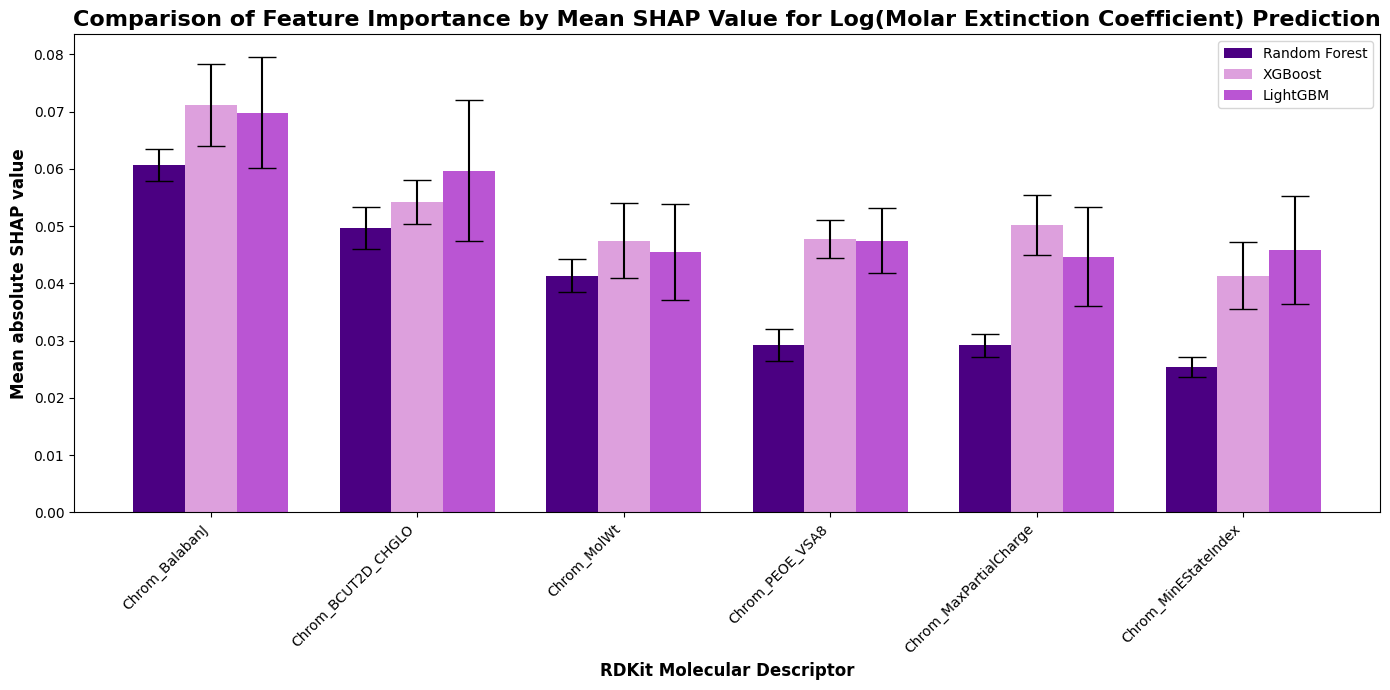

In [222]:
# generating the log(molar extinction coefficient) SHAP feature value
plot_mean_shap(rf_loge, xgb_loge, lgbm_loge, 
               title='Comparison of Feature Importance by Mean SHAP Value for Log(Molar Extinction Coefficient) Prediction')